![LIS](LIS.jpg)

# Applied Logistic Regression: NLP Classification
## Building a Profanity Detector with Word Embeddings

In the fundamentals notebook, we learned how logistic regression works mathematically. Now let's apply these concepts to a real-world NLP task: **detecting profanity in text**.

This notebook demonstrates:
1. How to represent words as numerical vectors (word embeddings)
2. How to prepare and balance training data
3. Training a logistic regression classifier on text data
4. Evaluating model performance with classification metrics
5. Testing the model on new, unseen words

In [2]:
!pip install spacy
import spacy
import numpy as np
import pandas as pd
import seaborn as sns
import random
sns.set()
!python -m spacy download en_core_web_md

from sklearn.metrics import (precision_score, f1_score, recall_score, 
                             accuracy_score, classification_report, 
                             confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached confection-0.1.5-py3-none-any.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 27.3 MB/s  0:00:00 eta 0:00:01
Using cached catalogue-2.0.10-py3-none-any.whl (17 kB)
Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl (29 kB)
Using cached spacy_loggers-1.0.5-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 651.7/651.7 kB 22.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.1/737.1 kB 23.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.6 MB/s  0:00:00
Using cached confection-0.1.5-py3-none-any.whl (35 kB)
Using cached wasabi-1.1.3-py3-none-any.whl (27 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [spacy]m13/14 [s

## Part 1: Word Embeddings - Representing Words as Numbers

Machine learning models work with numbers, not words. To classify text, we need to convert words into numerical representations. **Word embeddings** are dense vector representations that capture semantic meaning:

- Similar words have similar vectors
- The vectors capture relationships (king - man + woman ≈ queen)
- Each dimension represents some learned feature of language

We'll use **spaCy's pre-trained word vectors**. The medium model (`en_core_web_md`) includes 300-dimensional GloVe vectors for ~20,000 words.

**Setup**: If you haven't already, install the spaCy model:
```
python -m spacy download en_core_web_md
```

In [3]:
# Load spaCy with word vectors
import spacy

print("Loading spaCy model with word vectors...")
nlp = spacy.load("en_core_web_md")

print(f"Loaded! Vocabulary size: {len(nlp.vocab):,} entries")
print(f"Vector dimensions: {nlp.vocab.vectors.shape[1]}")
print(f"Words with vectors: {nlp.vocab.vectors.shape[0]:,}")

Loading spaCy model with word vectors...
Loaded! Vocabulary size: 764 entries
Vector dimensions: 300
Words with vectors: 20,000


In [4]:
# Explore word embeddings
example_word = "happy"
word_token = nlp.vocab[example_word]
vector = word_token.vector

print(f"The word '{example_word}' is represented by a {len(vector)}-dimensional vector:")
print(f"First 10 dimensions: {vector[:10].round(3)}")
print(f"...")
print(f"\nHas vector: {word_token.has_vector}")

# Find similar words using cosine similarity
def find_similar_words(word, nlp, n=5):
    """Find words most similar to the given word using cosine similarity."""
    word_vector = nlp.vocab[word].vector
    
    # Get all words with vectors
    similarities = []
    for other_word in nlp.vocab:
        if other_word.has_vector and other_word.is_lower and other_word.is_alpha:
            if other_word.text != word:
                similarity = np.dot(word_vector, other_word.vector) / (
                    np.linalg.norm(word_vector) * np.linalg.norm(other_word.vector) + 1e-8
                )
                similarities.append((other_word.text, similarity))
    
    # Sort by similarity and return top n
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:n]

print(f"\nWords most similar to '{example_word}':")
for word, similarity in find_similar_words(example_word, nlp):
    print(f"  {word}: {similarity:.3f}")

The word 'happy' is represented by a 300-dimensional vector:
First 10 dimensions: [-0.716  0.342 -0.777  0.262 -0.104  0.367  0.467 -0.144  0.577  2.591]
...

Has vector: True

Words most similar to 'happy':
  am: 1.000
  who: 0.544
  we: 0.544
  it: 0.535
  where: 0.535


## Part 2: Preparing the Training Data

For our profanity detector, we need:
1. **Positive examples (label=1)**: Profane/offensive words
2. **Negative examples (label=0)**: Non-profane/neutral words

**Important**: We need balanced classes—roughly equal numbers of each category. Otherwise, the model might just predict the majority class.

**Note**: The profanity list contains offensive content. This is necessary for training the classifier but may be disturbing to view directly.

In [5]:
# Load word lists
# Profane words from the dataset
profanity_df = pd.read_csv('profanity_en.csv')
profane_words = profanity_df['text'].tolist()

# Non-profane words from the VAD (Valence-Arousal-Dominance) lexicon
vad_df = pd.read_csv('Warriner_rescale.csv', index_col=0)
neutral_words = list(vad_df.index)

print(f"Profane words available: {len(profane_words)}")
print(f"Neutral words available: {len(neutral_words)}")

Profane words available: 1598
Neutral words available: 13915


In [25]:
profane_words

['69',
 '@55',
 '@ssfcker',
 '@ssfucker',
 '@ssfvcker',
 '@sshole',
 '0ral seks',
 '0ral sex',
 '0rg@sm',
 '0rgasms',
 '3jakulating',
 '4r5e',
 '4r5ed',
 '4r5es',
 '4skin',
 '5h17',
 '5h1t',
 '5kank',
 'a_s_s',
 'abbie',
 'abeed',
 'aboe',
 'anal',
 'anal hole',
 'anal hore',
 'anal pirate',
 'analingus',
 'analplug',
 'analplugs',
 'anilingus',
 'animal fucker',
 'anus',
 'anus plug',
 'ape shit',
 'ape shite',
 'apeshit',
 'apeshite',
 'ar5e',
 'ar5ehole',
 'arse',
 'arse gobbler',
 'arse hole',
 'arse-bandit',
 'arse-bandits',
 'arse-fucker',
 'arse-fuckers',
 'arse-hole',
 'arse-shagger',
 'arsefuck',
 'arsefucker',
 'arsehole',
 'arseshit',
 'arsewipe',
 'ashole',
 'ass',
 'ass bandit',
 'ass eating boiolas',
 'ass eating nob jokeys',
 'ass fecker',
 'ass fuck',
 'ass fucker',
 'ass fucking boiolas',
 'ass fucking nob jokeys',
 'ass hole',
 'ass kisser',
 'ass licking',
 'ass muncher',
 'ass-bandit',
 'ass-fucker',
 'ass-fuckers',
 'ass-hole',
 'asses',
 'assface',
 'assfck',
 'as

In [6]:
def get_word_vectors_spacy(word_list, nlp, max_words=None):
    """
    Get word embedding vectors for words in the list using spaCy.
    Only returns words that have vectors in the model.
    
    Parameters:
    -----------
    word_list : list
        List of words to look up
    nlp : spacy model
        Loaded spaCy model with word vectors
    max_words : int or None
        Maximum number of words to return (for balancing)
        
    Returns:
    --------
    words : list
        Words that were found in the model
    vectors : list
        Corresponding embedding vectors
    """
    words = []
    vectors = []
    
    for word in word_list:
        word_lower = str(word).lower().strip()
        token = nlp.vocab[word_lower]
        
        # Check if word has a vector (not all words do)
        if token.has_vector and np.any(token.vector):
            words.append(word_lower)
            vectors.append(token.vector)
    
    if max_words and len(words) > max_words:
        indices = random.sample(range(len(words)), max_words)
        words = [words[i] for i in indices]
        vectors = [vectors[i] for i in indices]
    
    return words, vectors

# Get vectors for profane words
profane_words_found, profane_vectors = get_word_vectors_spacy(profane_words, nlp)
print(f"Profane words with embeddings: {len(profane_words_found)}")

# Get balanced sample of neutral words
neutral_words_found, neutral_vectors = get_word_vectors_spacy(
    neutral_words, nlp, max_words=len(profane_words_found)
)
print(f"Neutral words (balanced sample): {len(neutral_words_found)}")

Profane words with embeddings: 492
Neutral words (balanced sample): 492


In [8]:
neutral_words_found

['rust',
 'catastrophic',
 'anesthetic',
 'syphilis',
 'feed',
 'emergency',
 'dock',
 'coleslaw',
 'sustenance',
 'caliber',
 'sill',
 'symposium',
 'pianist',
 'brash',
 'queen',
 'layover',
 'applicant',
 'ape',
 'buckle',
 'displease',
 'dryer',
 'obsessed',
 'receptionist',
 'announcement',
 'pose',
 'deny',
 'stewardess',
 'schnapps',
 'speedway',
 'physician',
 'lasting',
 'distinction',
 'manner',
 'quaint',
 'fickle',
 'venereal',
 'activate',
 'throne',
 'valium',
 'contemplate',
 'spacious',
 'leaky',
 'hassle',
 'fiasco',
 'conk',
 'discriminating',
 'toddler',
 'handgun',
 'calculation',
 'bruise',
 'indifference',
 'bunch',
 'hostess',
 'heartbreaking',
 'recon',
 'export',
 'vantage',
 'attendant',
 'suitcase',
 'melodrama',
 'penalty',
 'cholesterol',
 'incriminate',
 'bodily',
 'plaster',
 'foregone',
 'whopper',
 'rickshaw',
 'reprogram',
 'humanity',
 'promenade',
 'decryption',
 'spontaneous',
 'bipolar',
 'autobiographical',
 'sensitive',
 'downfield',
 'trapdoor',

In [9]:
# Create the training dataset
# Combine profane and neutral words
all_words = profane_words_found + neutral_words_found
all_vectors = profane_vectors + neutral_vectors
labels = [1] * len(profane_words_found) + [0] * len(neutral_words_found)

# Create DataFrame
vector_df = pd.DataFrame(all_vectors)
data = pd.DataFrame({
    'word': all_words,
    'label': labels
})
data = pd.concat([data, vector_df], axis=1)

print(f"Dataset shape: {data.shape}")
print(f"\nClass distribution:")
print(data['label'].value_counts())

# Preview (hiding actual profane words)
print(f"\nSample neutral words: {neutral_words_found[:5]}")
print(f"Number of features (embedding dimensions): {len(all_vectors[0])}")

Dataset shape: (984, 302)

Class distribution:
label
1    492
0    492
Name: count, dtype: int64

Sample neutral words: ['rust', 'catastrophic', 'anesthetic', 'syphilis', 'feed']
Number of features (embedding dimensions): 300


In [10]:
data

,word,label,0,1,2,3,4,5,6,7,...,290,291,292,293,294,295,296,297,298,299
0,69,1,-0.66934,0.614400,0.283690,0.147480,0.219580,-0.115270,-0.097255,0.257930,...,-0.623040,0.141520,-0.020668,0.604790,0.268500,-0.348950,-0.33326,0.069750,0.129630,0.109420
1,@sshole,1,-0.67638,-0.466290,-0.240850,0.040486,-0.013143,0.011026,-0.062135,-0.624560,...,0.365110,-0.220650,-0.252290,-0.468810,0.474630,0.163420,-0.16058,0.601730,-0.658510,0.092928
2,4skin,1,-1.08030,0.036741,-0.083051,0.199350,-0.361130,0.340190,0.039532,0.241970,...,-0.607140,0.099921,-0.233260,-0.327320,-0.806470,-0.389850,-0.33128,0.030984,-0.406370,-0.236170
3,abbie,1,-0.61214,0.515130,-0.018119,-0.206860,0.195910,-0.446760,0.476770,-0.022417,...,0.471670,-0.235020,-0.239440,-0.337010,0.369960,-0.213100,0.16129,0.430980,-0.271100,-0.283090
4,aboe,1,-0.87249,-0.371270,0.158390,0.136070,-0.088898,0.015629,0.839280,0.611560,...,-0.265040,-0.687230,-0.185090,-0.078402,0.573810,-0.458260,-0.38261,0.018842,0.254300,-0.221840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,blockbuster,0,-0.77720,-0.336650,0.111990,-0.233410,-0.182680,0.298700,0.302180,-0.171680,...,-0.098947,0.100500,-0.184610,0.145100,0.427790,0.029780,-0.13717,0.132560,0.263760,0.511740
980,snow,0,-0.67075,0.075303,0.054391,0.182050,0.410590,0.048702,-0.058925,0.796580,...,-0.128910,0.471180,0.086759,-0.780080,-0.139410,0.035524,0.23215,0.047629,-0.028228,-0.238300
981,compress,0,-0.80968,-0.431520,-0.096763,0.426510,-0.699990,0.411420,-0.179770,0.262950,...,-0.246820,0.540370,-0.077619,0.421310,-0.036568,0.069952,-0.15396,0.208010,0.201470,0.350130
982,piccolo,0,-0.63866,0.011132,-0.074541,0.097437,0.771230,0.045508,1.052000,0.218000,...,0.680150,-0.126970,0.705690,-0.006564,0.520010,0.745560,-0.49326,-0.491900,0.106600,0.425890


## Part 3: Training the Classifier

Now we'll:
1. Split data into training and test sets
2. Train a logistic regression model
3. Make predictions on the test set

In [11]:
# Prepare features and labels
X = data.drop(['word', 'label'], axis='columns')
y = data['label']

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())

Training set: 787 samples
Test set: 197 samples

Training class distribution:
label
1    394
0    393
Name: count, dtype: int64


In [12]:
# Train logistic regression classifier
classifier = LogisticRegression(random_state=42, max_iter=1000)
classifier.fit(X_train, y_train)

print("Model trained successfully!")
print(f"\nModel parameters:")
print(f"  Number of features: {classifier.n_features_in_}")
print(f"  Classes: {classifier.classes_}")

Model trained successfully!

Model parameters:
  Number of features: 300
  Classes: [0 1]


In [13]:
# Make predictions
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:, 1]  # Probability of being profane

print("Predictions made on test set!")

Predictions made on test set!


## Part 4: Evaluating Model Performance

Let's see how well our model distinguishes between profane and neutral words.

In [14]:
# Classification report
print("Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred, 
                           target_names=['Neutral', 'Profane']))

Classification Report
              precision    recall  f1-score   support

     Neutral       0.92      0.90      0.91        99
     Profane       0.90      0.92      0.91        98

    accuracy                           0.91       197
   macro avg       0.91      0.91      0.91       197
weighted avg       0.91      0.91      0.91       197



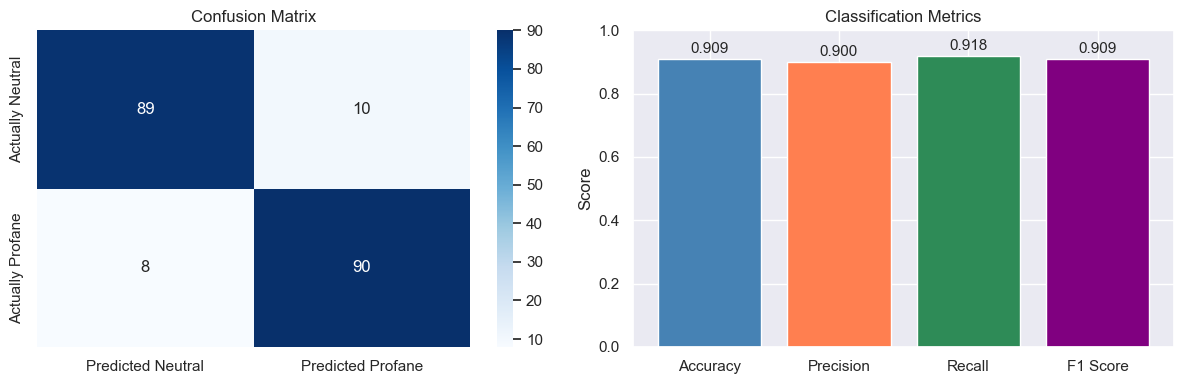

In [15]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['Predicted Neutral', 'Predicted Profane'],
           yticklabels=['Actually Neutral', 'Actually Profane'])
axes[0].set_title('Confusion Matrix')

# Metrics bar chart
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
}

bars = axes[1].bar(metrics.keys(), metrics.values(), 
                  color=['steelblue', 'coral', 'seagreen', 'purple'])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Score')
axes[1].set_title('Classification Metrics')
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### Interpreting the Results

- **Precision**: When the model predicts "profane", how often is it correct?
- **Recall**: Of all truly profane words, how many did the model catch?
- **F1 Score**: Harmonic mean of precision and recall

For a content moderation system:
- High **precision** means fewer false alarms (blocking innocent words)
- High **recall** means fewer profane words slip through

## Part 5: Testing on New Words

The real test: can our model classify words it hasn't seen during training? Let's try some edge cases—words that are unpleasant but not necessarily profane, and words that might seem offensive but aren't.

In [16]:
def predict_word(word, nlp, classifier):
    """
    Predict whether a word is profane using the trained classifier.
    
    Returns:
    --------
    prediction : str
        'Profane' or 'Neutral'
    probability : float
        Probability of being profane
    """
    token = nlp.vocab[word.lower()]
    
    if not token.has_vector or not np.any(token.vector):
        return 'Unknown', None
    
    vector = token.vector.reshape(1, -1)
    prob = classifier.predict_proba(vector)[0, 1]
    pred = 'Profane' if prob > 0.5 else 'Neutral'
    return pred, prob

# Test cases: mix of potentially offensive, unpleasant, and neutral words
test_words = [
    'happy', 'sad', 'angry',      # Emotions (neutral)
    'snot', 'scum', 'turd',       # Unpleasant but mild
    'stupid', 'idiot', 'fool',    # Insults (mild)
    'bigot', 'nazi', 'commie',    # Political terms
    'blood', 'death', 'kill',     # Violent words
    'love', 'peace', 'friend'     # Positive words
]

print("Testing the model on new words:")
print("=" * 50)

results = []
for word in test_words:
    pred, prob = predict_word(word, nlp, classifier)
    results.append({'word': word, 'prediction': pred, 'probability': prob})
    if prob is not None:
        marker = '*' if pred == 'Profane' else ' '
        print(f"{marker} {word:12} -> {pred:8} (P(profane) = {prob:.2%})")
    else:
        print(f"  {word:12} -> Word not in vocabulary")

Testing the model on new words:
  happy        -> Neutral  (P(profane) = 0.06%)
  sad          -> Neutral  (P(profane) = 10.38%)
  angry        -> Neutral  (P(profane) = 0.61%)
  snot         -> Neutral  (P(profane) = 15.07%)
* scum         -> Profane  (P(profane) = 73.71%)
* turd         -> Profane  (P(profane) = 74.23%)
  stupid       -> Neutral  (P(profane) = 2.73%)
  idiot        -> Neutral  (P(profane) = 40.70%)
  fool         -> Neutral  (P(profane) = 12.26%)
  bigot        -> Neutral  (P(profane) = 15.51%)
  nazi         -> Neutral  (P(profane) = 14.88%)
* commie       -> Profane  (P(profane) = 92.64%)
  blood        -> Neutral  (P(profane) = 0.70%)
  death        -> Neutral  (P(profane) = 3.36%)
  kill         -> Neutral  (P(profane) = 0.43%)
  love         -> Neutral  (P(profane) = 1.22%)
  peace        -> Neutral  (P(profane) = 0.20%)
  friend       -> Neutral  (P(profane) = 42.84%)


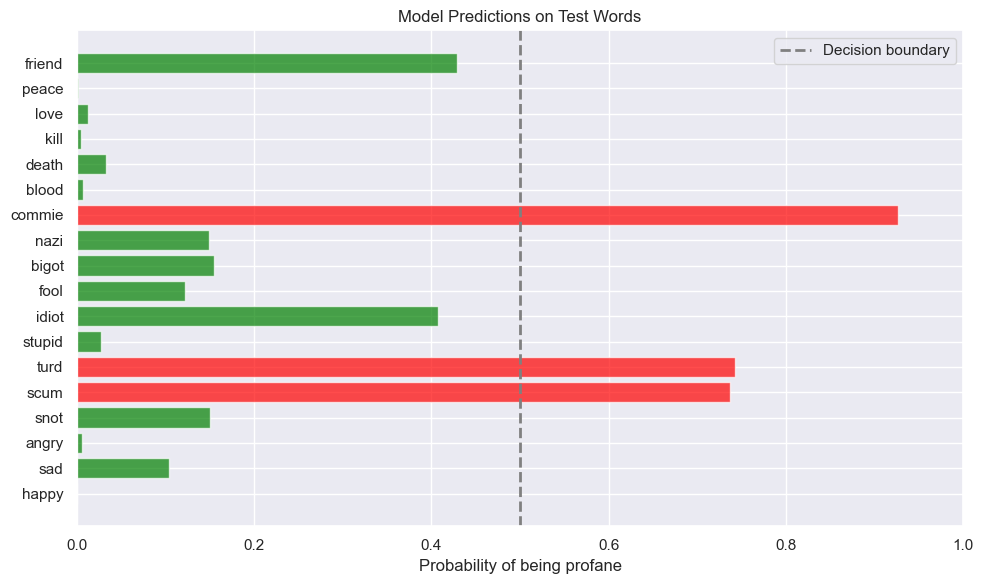

In [17]:
# Visualize test results
results_df = pd.DataFrame(results)
results_df = results_df.dropna()  # Remove unknown words

plt.figure(figsize=(10, 6))
colors = ['red' if p > 0.5 else 'green' for p in results_df['probability']]
bars = plt.barh(results_df['word'], results_df['probability'], color=colors, alpha=0.7)
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, label='Decision boundary')
plt.xlabel('Probability of being profane')
plt.title('Model Predictions on Test Words')
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
predict_word("ballbag", nlp, classifier)

('Profane', np.float64(0.9702859966098485))

## Part 6: Understanding Model Limitations

Our simple profanity detector has several limitations:

1. **Single words only**: Can't understand context ("kill time" vs threatening language)
2. **Limited vocabulary**: Words not in spaCy's vocabulary can't be classified
3. **Training data bias**: The model reflects biases in the profanity list used for training
4. **No context awareness**: "That's sick!" (cool) vs "I feel sick" (unwell)

More advanced approaches use:
- Sentence-level embeddings
- Transformer models (BERT, GPT)
- Context-aware classification

## Summary

In this notebook, we applied logistic regression to an NLP classification task:

1. **Word embeddings**: Converted words to numerical vectors using spaCy's pre-trained vectors
2. **Data preparation**: Created balanced training data with profane/neutral labels
3. **Model training**: Trained logistic regression on 300-dimensional word vectors
4. **Evaluation**: Used precision, recall, F1, and confusion matrices
5. **Deployment**: Tested on unseen words to check generalization

This same pattern—embed -> classify -> evaluate—applies to many NLP tasks:
- Spam detection
- Sentiment analysis
- Topic classification
- Intent detection

## Exercises

### Exercise 1: Try Different Words
Add your own test words to see how the model classifies them.

In [ ]:
# Exercise 1: Test your own words
my_test_words = ['wonderful', 'terrible', 'awesome']  # Add your own words here

print("Your test results:")
for word in my_test_words:
    pred, prob = predict_word(word, nlp, classifier)
    if prob is not None:
        print(f"  {word}: {pred} (P={prob:.2%})")
    else:
        print(f"  {word}: Not in vocabulary")

### Exercise 2: Adjust the Decision Threshold
What happens if we make the model more or less strict?

In [ ]:
# Exercise 2: Different thresholds
thresholds = [0.3, 0.5, 0.7, 0.9]

print("Effect of different thresholds:")
print("-" * 60)

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    n_flagged = sum(y_pred_thresh)
    print(f"Threshold {thresh}: F1={f1:.3f}, Words flagged as profane: {n_flagged}/{len(y_test)}")

### Exercise 3: Compare Word Vectors
Explore how similar or different words are in the embedding space.

In [ ]:
# Exercise 3: Explore word similarity
def word_similarity(word1, word2, nlp):
    """Calculate cosine similarity between two words."""
    vec1 = nlp.vocab[word1].vector
    vec2 = nlp.vocab[word2].vector
    
    if not np.any(vec1) or not np.any(vec2):
        return None
    
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Compare pairs of words
word_pairs = [
    ('happy', 'joyful'),
    ('happy', 'sad'),
    ('king', 'queen'),
    ('good', 'evil'),
    ('cat', 'dog'),
    ('cat', 'computer')
]

print("Word pair similarities:")
print("-" * 40)
for w1, w2 in word_pairs:
    sim = word_similarity(w1, w2, nlp)
    if sim is not None:
        print(f"  {w1:10} <-> {w2:10}: {sim:.3f}")
    else:
        print(f"  {w1:10} <-> {w2:10}: (no vector)")